   first  second  final_score
0   0.99   -0.99     0.894918
1   0.35   -0.89    -0.696835
2   0.47   -0.19     0.276923
3   0.44   -0.68    -0.901706
4   0.67   -0.90    -0.493966


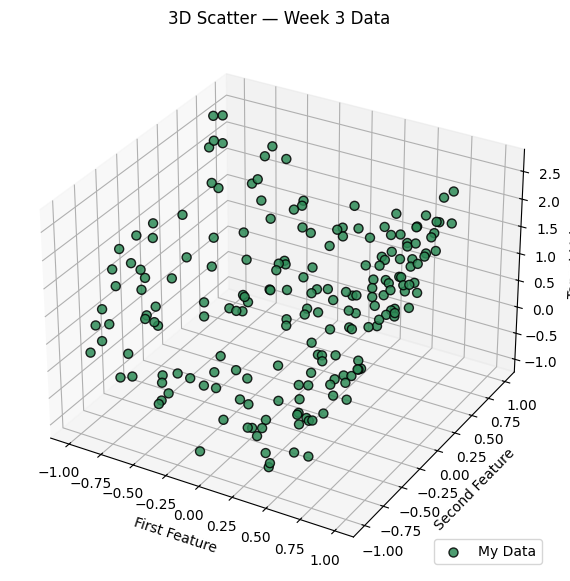

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv('week3.csv', header=None, skiprows=1)
df.columns = ['first', 'second', 'final_score']

# Just to be sure, always peek at the data
print(df.head())

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['first'], df['second'], df['final_score'],
           c='seagreen', 
           s=42,         # Slightly larger dots for style
           edgecolor='black', 
           alpha=0.85,   # Not fully opaque, so some overlap is visible
           label='My Data')

ax.set_xlabel('First Feature')
ax.set_ylabel('Second Feature')
ax.set_zlabel('Target Value')
ax.set_title('3D Scatter — Week 3 Data')
ax.legend(loc='lower right')
plt.show()


In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso

# Load and label data
df = pd.read_csv('week3.csv', header=None, skiprows=1)
df.columns = ['first', 'second', 'final_score']
X = df[['first', 'second']].values
y = df['final_score'].values

# Polynomial features, up to 5th degree
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X)

# Model parameters
C_list = [0.1, 1, 10, 100]
feature_names = poly.get_feature_names_out(['first', 'second'])

for C in C_list:
    lasso = Lasso(alpha=1/C, max_iter=10000)
    lasso.fit(X_poly, y)
    coefs = lasso.coef_
    print(f"\nC = {C}:")
    print("Feature         | Coefficient")
    print("----------------|------------")

    # Print only the ones that are above a small threshold
    for fname, coeff in zip(feature_names, coefs):
        if abs(coeff) > 0.01:           # Only display 'important' features
            print(f"{fname:14} | {coeff:.3f}")



C = 0.1:
Feature         | Coefficient
----------------|------------

C = 1:
Feature         | Coefficient
----------------|------------

C = 10:
Feature         | Coefficient
----------------|------------
second         | 0.558
first^2        | 0.698

C = 100:
Feature         | Coefficient
----------------|------------
second         | 0.935
first^2        | 1.840


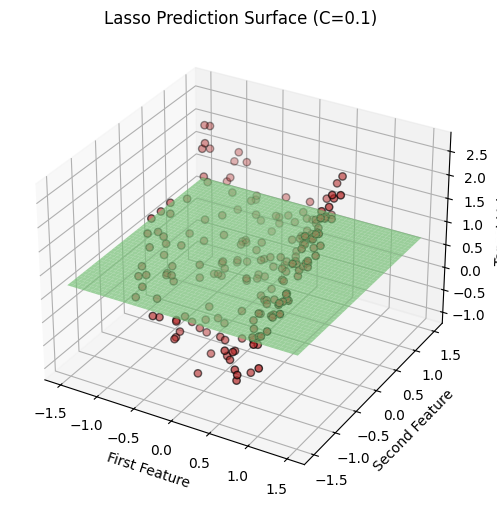

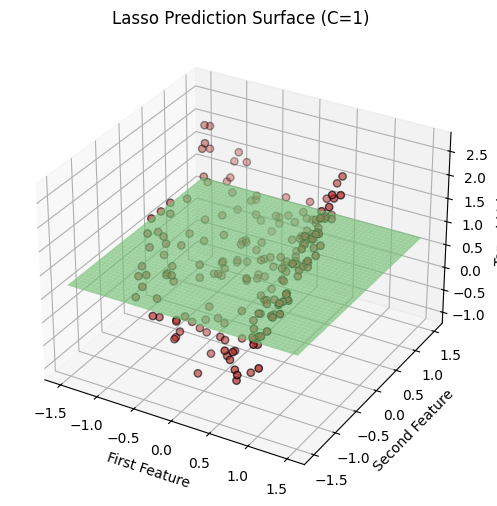

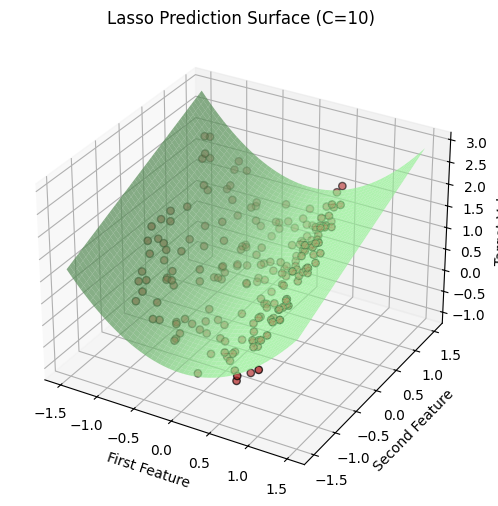

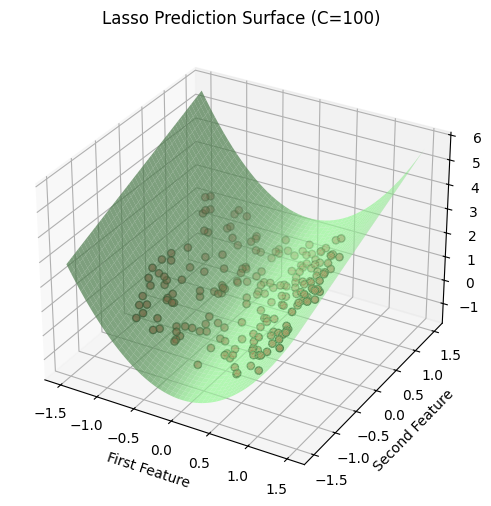

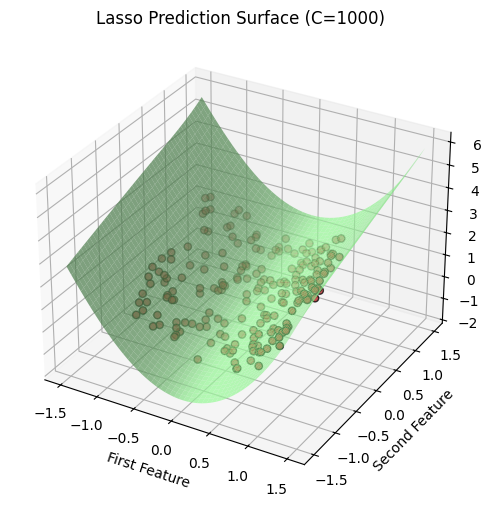

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Setting up a grid (from -1.5 to 1.5) is usually safe for your dataset range
grid = np.linspace(-1.5, 1.5, 50)
f1, f2 = np.meshgrid(grid, grid)
X_grid = np.column_stack([f1.ravel(), f2.ravel()])
X_grid_poly = poly.transform(X_grid)

for C in [0.1, 1, 10, 100,1000]:
    lasso = Lasso(alpha=1/C, max_iter=10000)
    lasso.fit(X_poly, y)
    preds = lasso.predict(X_grid_poly).reshape(f1.shape)
    
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    
    # Surface in 'palegreen', points in 'firebrick'
    ax.plot_surface(f1, f2, preds, color='palegreen', alpha=0.7)
    ax.scatter(df['first'], df['second'], df['final_score'], 
               c='firebrick', s=28, edgecolor='black')
    
    ax.set_xlabel('First Feature')
    ax.set_ylabel('Second Feature')
    ax.set_zlabel('Target Value')
    ax.set_title(f'Lasso Prediction Surface (C={C})')
    plt.show()


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Load and label your data (reuse if already loaded)
df = pd.read_csv('week3.csv', header=None, skiprows=1)
df.columns = ['first', 'second', 'final_score']
X = df[['first', 'second']].values
y = df['final_score'].values

# Polynomial features (degree 5)
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(['first', 'second'])

ridge_C_list = [0.1, 1, 10, 100]

for C in ridge_C_list:
    # Ridge uses alpha directly as penalty, the inverse of C
    ridge = Ridge(alpha=1/C, max_iter=10000)
    ridge.fit(X_poly, y)
    coefs = ridge.coef_
    print(f"\nC = {C} (Ridge):")
    print("Feature         | Coefficient")
    print("----------------|-------------")
    for fname, coeff in zip(feature_names, coefs):
        if abs(coeff) > 0.01:
            print(f"{fname:14} | {coeff:.3f}")



C = 0.1 (Ridge):
Feature         | Coefficient
----------------|-------------
first          | 0.029
second         | 0.613
first^2        | 0.812
second^2       | -0.053
first^3        | 0.032
first^2 second | 0.087
first second^2 | -0.049
second^3       | 0.228
first^4        | 0.656
first^2 second^2 | 0.224
first second^3 | -0.012
second^4       | -0.017
first^5        | 0.021
first^2 second^3 | 0.017
first second^4 | -0.041
second^5       | 0.101

C = 1 (Ridge):
Feature         | Coefficient
----------------|-------------
second         | 0.876
first^2        | 1.315
first second   | -0.087
second^2       | -0.090
first second^2 | -0.014
second^3       | 0.129
first^4        | 0.575
first^3 second | 0.106
first^2 second^2 | 0.234
first second^3 | 0.043
first^5        | 0.051
first^4 second | 0.017
first^3 second^2 | 0.171
first second^4 | -0.110
second^5       | 0.015

C = 10 (Ridge):
Feature         | Coefficient
----------------|-------------
first          | 0.074
second       

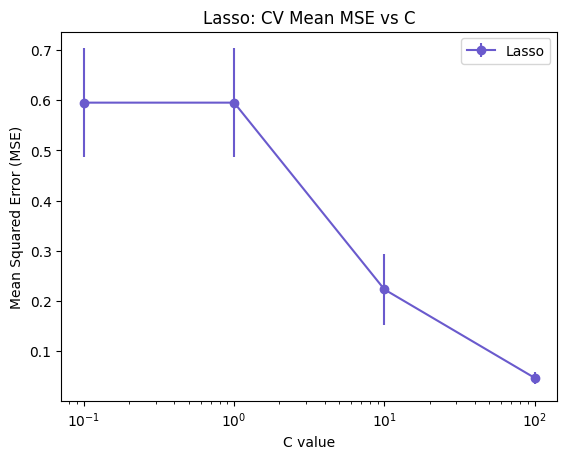

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Data loading
df = pd.read_csv('week3.csv', header=None, skiprows=1)
df.columns = ['first', 'second', 'final_score']
X = df[['first', 'second']].values
y = df['final_score'].values

# Polynomial features
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X)

C_list = [0.1, 1, 10, 100]
lasso_means = []
lasso_stds = []

for C in C_list:
    lasso = Lasso(alpha=1/C, max_iter=10000)
    # Negative mean squared error, flipped
    scores = cross_val_score(lasso, X_poly, y, cv=5, scoring='neg_mean_squared_error')
    lasso_means.append(-np.mean(scores))
    lasso_stds.append(np.std(scores))

plt.errorbar(C_list, lasso_means, yerr=lasso_stds, fmt='-o', color='slateblue', label='Lasso')
plt.xlabel('C value')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Lasso: CV Mean MSE vs C')
plt.xscale('log')
plt.legend()
plt.show()


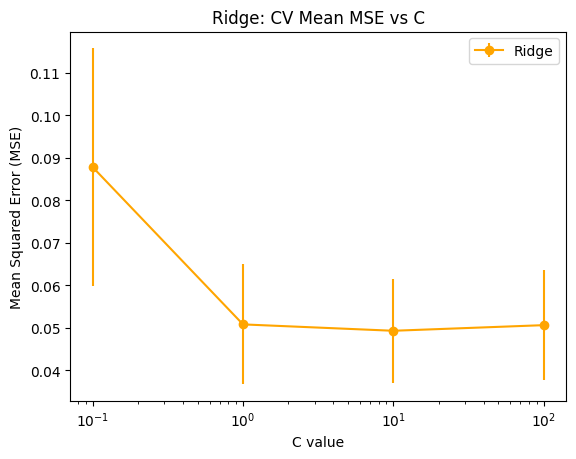

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Data loading
df = pd.read_csv('week3.csv', header=None, skiprows=1)
df.columns = ['first', 'second', 'final_score']
X = df[['first', 'second']].values
y = df['final_score'].values

# Polynomial features
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X)

C_list = [0.1, 1, 10, 100]
ridge_means = []
ridge_stds = []

for C in C_list:
    ridge = Ridge(alpha=1/C, max_iter=10000)
    scores = cross_val_score(ridge, X_poly, y, cv=5, scoring='neg_mean_squared_error')
    ridge_means.append(-np.mean(scores))
    ridge_stds.append(np.std(scores))

plt.errorbar(C_list, ridge_means, yerr=ridge_stds, fmt='-o', color='orange', label='Ridge')
plt.xlabel('C value')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Ridge: CV Mean MSE vs C')
plt.xscale('log')
plt.legend()
plt.show()
